# US Firm Characteristics: Label Engineering

This notebook implements label engineering for the cross-sectional factor
investing case study. Labels encode the hypothesis: can firm characteristics
predict one-month-ahead stock returns in the cross-section?

## Learning Objectives

- Preserve the released split-scoped anonymous firm identity
- Use the provider-aligned one-month return as the prediction target
- Build canonical walk-forward splits with 10-year training / 1-year validation windows
- Evaluate label quality: return distributions, cross-sectional dispersion
- Create classification labels via cross-sectional median split

## Book Reference

Chapter 7, Section 7.2 (Label Engineering)

## Prerequisites

- [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) must have been run (produces feasibility report)
- Firm characteristics data available via `load_firm_characteristics()`

## Key Insight

This dataset is pre-processed by Chen, Pelger, and Zhu (2020): characteristics
are cross-sectionally rank-transformed to $[-0.5, 0.5]$, returns are raw, and
stocks are anonymized (no PERMNO). The released tensors preserve a fixed firm
axis within each train, validation, and test block, and the public converter
carries that axis forward as `symbol`. The provider has already aligned each
row's characteristics with the following monthly return in `ret`.

In [1]:
"""US Firm Characteristics: Label Engineering."""

import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from matplotlib.ticker import PercentFormatter
from ml4t.diagnostic.metrics import compute_ic_hac_stats

from data import load_firm_characteristics
from utils.cv_splits import generate_cv_splits
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, add_message_title

CASE_DIR = get_case_study_dir("us_firm_characteristics")
LABELS_DIR = CASE_DIR / "labels"
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
START_DATE = "1990-01-01"
MAX_SYMBOLS = 0

## 1. Load Data

The Chen-Pelger-Zhu (2020) dataset provides 46 firm characteristics and
monthly returns for US equities from 1967 to 2016. Stocks are anonymized, but
the released tensors preserve a persistent anonymous firm axis within each
published split. Each retained row is a complete (firm, month) observation.

We restrict to the 1990--2016 period for our study (matches setup.yaml).

In [3]:
firm_chars = load_firm_characteristics(split="all").with_columns(pl.col("timestamp").cast(pl.Date))

# Filter to study period
START_DATE = "1990-01-01"
END_DATE = "2016-12-31"
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])

firm_chars = firm_chars.filter(
    (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
)
holdout_start_dt = pl.lit(HOLDOUT_START).str.to_date()

n_dates = firm_chars["timestamp"].n_unique()
avg_stocks = len(firm_chars) / max(n_dates, 1)
print(f"Firm characteristics: {len(firm_chars):,} rows, {n_dates} months")
print(f"Average stocks per month: {avg_stocks:.0f}")
print(f"Period: {firm_chars['timestamp'].min()} to {firm_chars['timestamp'].max()}")
print(f"Persistent anonymous firms: {firm_chars['symbol'].n_unique():,}")
print(f"Columns: {len(firm_chars.columns)} (46 characteristics plus canonical metadata)")

Firm characteristics: 804,530 rows, 324 months
Average stocks per month: 2483
Period: 1990-01-31 to 2016-12-30
Persistent anonymous firms: 9,861
Columns: 50 (46 characteristics plus canonical metadata)


## 2. Label Construction

### Primary: 1-Month Forward Return

Following the standard convention in Gu, Kelly, and Xiu (2020) and Chen,
Pelger, and Zhu (2022), each row pairs characteristics measured at the
end of month $t-1$ with the stock's return during month $t$. The `ret`
column is therefore a **forward return** relative to the information set:
the model predicts month $t$'s return using only information available
before it is realized. The provider updates annual variables at the end of
June and monthly variables at month-end for the next month.

No explicit shifting is needed because the data provider has already
aligned characteristics and returns with the correct temporal offset.
This is the standard setup in the empirical asset pricing literature.

The anonymous identifiers persist within each source tensor block. All
operational folds and the 2016 holdout fall within the 1992-2016 test block.
The variants below transform the same provider-aligned one-month target.

In [4]:
# Forward return: characteristics at t-1, return during t
labels_df = firm_chars.with_columns(pl.col("ret").alias("fwd_ret_1m"))

n_with_label = labels_df.filter(pl.col("fwd_ret_1m").is_not_null()).shape[0]
print(f"1-month forward return labels: {n_with_label:,} observations")
print(f"Missing: {len(labels_df) - n_with_label:,}")

1-month forward return labels: 804,530 observations
Missing: 0


### Variant 1: Classification (Above/Below Median)

Binary classification label: 1 if the stock's forward 1-month return exceeds
the cross-sectional median for that month, 0 otherwise. This is a relative
ranking label that is robust to market-level return variation.

In [5]:
# Cross-sectional median at each date
monthly_medians = (
    labels_df.filter(pl.col("fwd_ret_1m").is_not_null())
    .group_by("timestamp")
    .agg(pl.col("fwd_ret_1m").median().alias("median_ret_1m"))
)

labels_df = labels_df.join(monthly_medians, on="timestamp", how="left")

labels_df = labels_df.with_columns(
    pl.when(pl.col("fwd_ret_1m").is_not_null())
    .then(pl.when(pl.col("fwd_ret_1m") > pl.col("median_ret_1m")).then(1).otherwise(0))
    .otherwise(None)
    .cast(pl.Int32)
    .alias("fwd_class_1m")
)

n_class = labels_df.filter(pl.col("fwd_class_1m").is_not_null()).shape[0]
class_diagnostic = labels_df.filter(
    (pl.col("timestamp") < holdout_start_dt) & pl.col("fwd_class_1m").is_not_null()
)
class_balance = class_diagnostic.group_by("fwd_class_1m").len()
print(f"Classification labels saved: {n_class:,} observations")
print(f"Pre-holdout class balance ({len(class_diagnostic):,} observations):")
for row in class_balance.sort("fwd_class_1m").iter_rows(named=True):
    pct = row["len"] / len(class_diagnostic) * 100
    print(f"  Class {row['fwd_class_1m']}: {row['len']:,} ({pct:.1f}%)")

Classification labels saved: 804,530 observations
Pre-holdout class balance (780,882 observations):
  Class 0: 392,012 (50.2%)
  Class 1: 388,870 (49.8%)


## 3. Label Quality Assessment

Label diagnostics use train plus validation only. The 2016 holdout labels are
constructed and saved but never summarized here. We inspect outliers and
define a within-month 1st/99th percentile winsorized target.

In [6]:
analysis_labels = labels_df.filter(pl.col("timestamp") < holdout_start_dt)

# Return distribution by source tensor block, pre-holdout only
ret_stats = (
    analysis_labels.filter(pl.col("fwd_ret_1m").is_not_null())
    .group_by("split")
    .agg(
        pl.col("fwd_ret_1m").mean().alias("mean"),
        pl.col("fwd_ret_1m").std().alias("std"),
        pl.col("fwd_ret_1m").quantile(0.01).alias("p01"),
        pl.col("fwd_ret_1m").quantile(0.99).alias("p99"),
        pl.col("fwd_ret_1m").min().alias("min"),
        pl.col("fwd_ret_1m").max().alias("max"),
        pl.len().alias("n"),
    )
    .sort("split")
)

print(f"1-Month Return Distribution by Source Block (pre-holdout, < {HOLDOUT_START}):")
print(ret_stats)

1-Month Return Distribution by Source Block (pre-holdout, < 2016-01-01):
shape: (2, 8)
┌───────┬──────────┬──────────┬───────────┬──────────┬───────────┬─────────┬────────┐
│ split ┆ mean     ┆ std      ┆ p01       ┆ p99      ┆ min       ┆ max     ┆ n      │
│ ---   ┆ ---      ┆ ---      ┆ ---       ┆ ---      ┆ ---       ┆ ---     ┆ ---    │
│ str   ┆ f64      ┆ f64      ┆ f64       ┆ f64      ┆ f64       ┆ f64     ┆ u32    │
╞═══════╪══════════╪══════════╪═══════════╪══════════╪═══════════╪═════════╪════════╡
│ test  ┆ 0.011305 ┆ 0.173106 ┆ -0.372549 ┆ 0.543387 ┆ -0.960633 ┆ 18.9975 ┆ 726627 │
│ valid ┆ 0.006191 ┆ 0.189456 ┆ -0.368936 ┆ 0.573978 ┆ -0.933471 ┆ 10.9943 ┆ 54255  │
└───────┴──────────┴──────────┴───────────┴──────────┴───────────┴─────────┴────────┘


In [7]:
# Winsorize labels at 1st/99th percentile (for robust evaluation)
# Compute per-month boundaries
win_bounds = (
    labels_df.filter(pl.col("fwd_ret_1m").is_not_null())
    .group_by("timestamp")
    .agg(
        pl.col("fwd_ret_1m").quantile(0.01).alias("p01"),
        pl.col("fwd_ret_1m").quantile(0.99).alias("p99"),
    )
)

labels_df = labels_df.join(win_bounds, on="timestamp", how="left", suffix="_win")

labels_df = labels_df.with_columns(
    pl.col("fwd_ret_1m").clip(pl.col("p01"), pl.col("p99")).alias("fwd_ret_1m_win")
)

winsorized_stats = labels_df.filter(
    (pl.col("timestamp") < holdout_start_dt) & pl.col("fwd_ret_1m_win").is_not_null()
).select(
    pl.col("fwd_ret_1m_win").mean().alias("mean"),
    pl.col("fwd_ret_1m_win").std().alias("std"),
    pl.col("fwd_ret_1m_win").min().alias("min"),
    pl.col("fwd_ret_1m_win").max().alias("max"),
)
print("\nWinsorized (1st/99th pctile) 1-month return:")
print(winsorized_stats)


Winsorized (1st/99th pctile) 1-month return:
shape: (1, 4)
┌─────────┬──────────┬───────────┬──────────┐
│ mean    ┆ std      ┆ min       ┆ max      │
│ ---     ┆ ---      ┆ ---       ┆ ---      │
│ f64     ┆ f64      ┆ f64       ┆ f64      │
╞═════════╪══════════╪═══════════╪══════════╡
│ 0.00878 ┆ 0.148502 ┆ -0.697096 ┆ 1.668597 │
└─────────┴──────────┴───────────┴──────────┘


The raw and winsorized distributions overlap through the center. The
difference is confined to the extreme one-percent tails, which reduces their
influence without changing the cross-sectional ordering of ordinary returns.

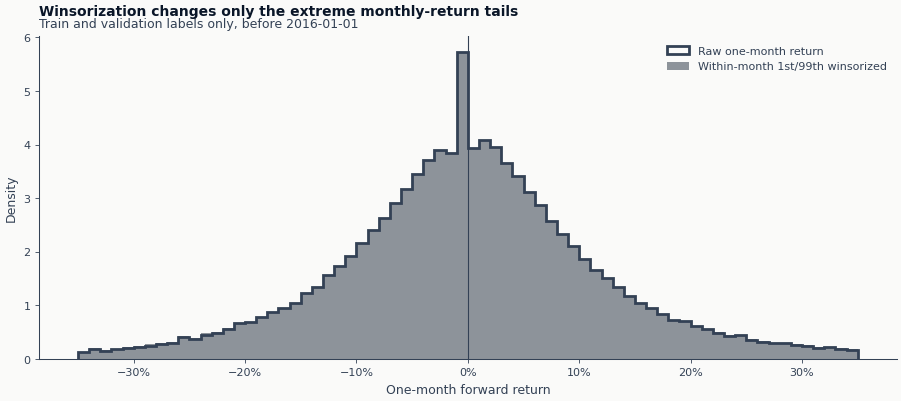

In [8]:
plot_sample = labels_df.filter(pl.col("timestamp") < holdout_start_dt).select(
    "fwd_ret_1m", "fwd_ret_1m_win"
)
raw_returns = plot_sample["fwd_ret_1m"].to_numpy()
win_returns = plot_sample["fwd_ret_1m_win"].to_numpy()
bins = np.linspace(-0.35, 0.35, 71)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    raw_returns,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    color=COLORS["neutral"],
    label="Raw one-month return",
)
ax.hist(
    win_returns,
    bins=bins,
    density=True,
    alpha=0.45,
    color=COLORS["blue"],
    label="Within-month 1st/99th winsorized",
)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xlabel("One-month forward return")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
add_message_title(
    ax,
    "Winsorization changes only the extreme monthly-return tails",
    f"Train and validation labels only, before {HOLDOUT_START}",
)
ax.legend(loc="upper right")
fig.show()

## 4. Baseline IC: Raw Characteristics vs Forward Returns

Before feature engineering, we measure the pre-holdout IC of seven declared
raw characteristics. The statistic is one Spearman correlation per month,
averaged over time with Newey-West HAC inference. This is a diagnostic
benchmark, not feature selection.

In [9]:
def compute_xs_ic(
    df: pl.DataFrame,
    signal_col: str,
    label_col: str = "fwd_ret_1m",
    min_obs: int = 100,
) -> pl.DataFrame:
    """Compute cross-sectional rank IC at each date.

    Returns one IC value per date where both signal and label are non-null.
    """
    valid = df.filter(pl.col(signal_col).is_not_null() & pl.col(label_col).is_not_null())

    ic_by_date = (
        valid.group_by("timestamp")
        .agg(
            pl.corr(signal_col, label_col, method="spearman").alias("ic"),
            pl.len().alias("n"),
        )
        .filter(pl.col("n") >= min_obs)
        .sort("timestamp")
    )
    return ic_by_date

In [10]:
# Check IC for key characteristics using train plus validation only
key_chars = ["BEME", "PROF", "ROE", "Investment", "r12_2", "IdioVol", "LME"]
baseline_ics = {}

for char in key_chars:
    if char not in analysis_labels.columns:
        continue
    ic_series = compute_xs_ic(analysis_labels, char)
    if len(ic_series) > 0:
        stats = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=1)
        baseline_ics[char] = stats
        print(
            f"  {char:15s}: IC={stats['mean_ic']:+.4f}, "
            f"HAC t={stats['t_stat']:+.2f}, p={stats['p_value']:.3f} "
            f"({stats['n_periods']} months, lag={stats['effective_lags']})"
        )

  BEME           : IC=+0.0044, HAC t=+0.92, p=0.359 (312 months, lag=5)
  PROF           : IC=+0.0233, HAC t=+6.19, p=0.000 (312 months, lag=5)


  ROE            : IC=+0.0355, HAC t=+7.02, p=0.000 (312 months, lag=5)
  Investment     : IC=+0.0062, HAC t=+1.46, p=0.145 (312 months, lag=5)


  r12_2          : IC=+0.0440, HAC t=+6.14, p=0.000 (312 months, lag=5)
  IdioVol        : IC=-0.0570, HAC t=-7.99, p=0.000 (312 months, lag=5)


  LME            : IC=+0.0421, HAC t=+7.39, p=0.000 (312 months, lag=5)


**Interpretation**: The raw-characteristic ICs set a narrow, pre-holdout
benchmark for Chapter 8. HAC uncertainty is based on the monthly IC series,
so the large number of firms in each cross-section does not masquerade as an
equally large time-series sample.

### Pre-Holdout IC Benchmark

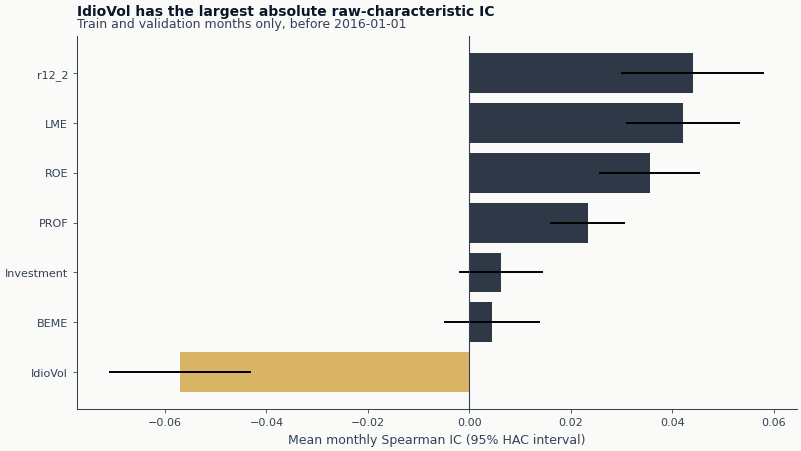

In [11]:
ic_chart = pl.DataFrame(
    {
        "characteristic": list(baseline_ics),
        "mean_ic": [baseline_ics[name]["mean_ic"] for name in baseline_ics],
        "hac_se": [baseline_ics[name]["hac_se"] for name in baseline_ics],
    }
).sort("mean_ic")
leader = max(baseline_ics, key=lambda name: abs(baseline_ics[name]["mean_ic"]))

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(ic_chart))
means = ic_chart["mean_ic"].to_numpy()
errors = 1.96 * ic_chart["hac_se"].to_numpy()
colors = [COLORS["blue"] if value >= 0 else COLORS["amber"] for value in means]
ax.barh(y, means, xerr=errors, color=colors, alpha=0.85, capsize=3)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_yticks(y, ic_chart["characteristic"].to_list())
ax.set_xlabel("Mean monthly Spearman IC (95% HAC interval)")
add_message_title(
    ax,
    f"{leader} has the largest absolute raw-characteristic IC",
    f"Train and validation months only, before {HOLDOUT_START}",
)
fig.show()

## 5. Walk-Forward CV Configuration

The canonical splitter reads `setup.yaml`: 10 backward-generated folds,
10-year rolling training windows, one-year validation windows, a one-month
label buffer, and a sealed 2016 holdout. Each validation fold contributes 11
observed months after the buffer.

In [12]:
splits = generate_cv_splits(
    labels_df.select("timestamp"),
    setup_path=CASE_DIR / "config" / "setup.yaml",
    label_buffer=str(SETUP["labels"]["buffer"]),
)

print(f"Walk-forward splits: {len(splits)} folds")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {s['train_start'].date()} to {s['train_end'].date()}, "
        f"validation {s['val_start'].date()} to {s['val_end'].date()}"
    )

assert len(splits) == int(SETUP["evaluation"]["n_splits"])
assert max(split["val_end"] for split in splits).date().isoformat() < HOLDOUT_START

Walk-forward splits: 10 folds
  Fold 0: train 2005-03-31 to 2014-12-31, validation 2015-02-27 to 2015-12-31
  Fold 1: train 2004-04-30 to 2014-02-28, validation 2014-03-31 to 2015-01-30
  Fold 2: train 2003-05-30 to 2013-03-28, validation 2013-04-30 to 2014-02-28
  Fold 3: train 2002-06-28 to 2012-04-30, validation 2012-05-31 to 2013-03-28
  Fold 4: train 2001-07-31 to 2011-04-29, validation 2011-06-30 to 2012-04-30
  Fold 5: train 2000-08-31 to 2010-05-28, validation 2010-07-30 to 2011-05-31
  Fold 6: train 1999-09-30 to 2009-07-31, validation 2009-08-31 to 2010-06-30
  Fold 7: train 1998-10-30 to 2008-08-29, validation 2008-09-30 to 2009-07-31
  Fold 8: train 1997-11-28 to 2007-09-28, validation 2007-10-31 to 2008-08-29
  Fold 9: train 1996-12-31 to 2006-09-29, validation 2006-11-30 to 2007-09-28


## 6. Cross-Sectional Dispersion Over Time

Cross-sectional return dispersion determines the payoff scale available to a
sorting strategy, but it does not establish predictability. We measure how
that scale changes through the pre-holdout sample.

In [13]:
dispersion = (
    analysis_labels.filter(pl.col("fwd_ret_1m").is_not_null())
    .group_by("timestamp")
    .agg(
        pl.col("fwd_ret_1m").std().alias("xs_std"),
        pl.col("fwd_ret_1m").mean().alias("xs_mean"),
        pl.len().alias("n_stocks"),
        (pl.col("fwd_ret_1m").quantile(0.9) - pl.col("fwd_ret_1m").quantile(0.1)).alias(
            "iqr_90_10"
        ),
    )
    .sort("timestamp")
)

print("Cross-sectional return dispersion summary:")
print(f"  Mean XS-Std: {dispersion['xs_std'].mean():.4f}")
print(f"  Mean 90-10 IQR: {dispersion['iqr_90_10'].mean():.4f}")
print(f"  Min XS-Std: {dispersion['xs_std'].min():.4f} (compression month)")
print(f"  Max XS-Std: {dispersion['xs_std'].max():.4f} (dispersion month)")

Cross-sectional return dispersion summary:
  Mean XS-Std: 0.1576
  Mean 90-10 IQR: 0.2969
  Min XS-Std: 0.0908 (compression month)
  Max XS-Std: 0.4299 (dispersion month)


Annual averaging separates persistent changes in cross-sectional opportunity
from one-month tail events. Dispersion varies through time, but it remains
economically material throughout the pre-holdout sample.

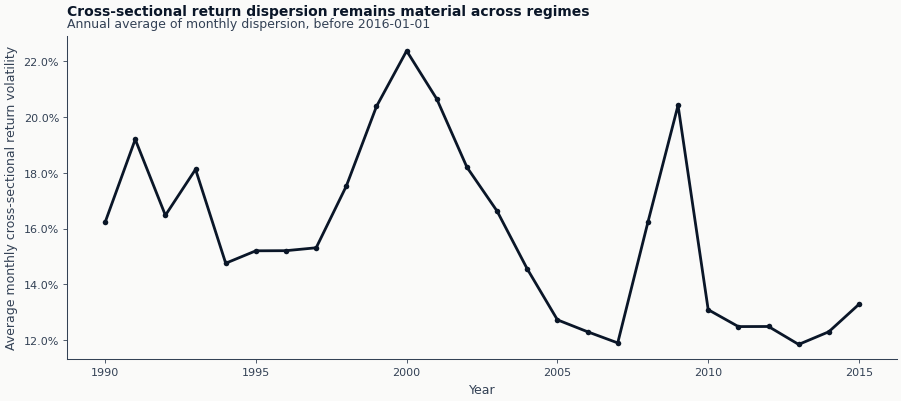

In [14]:
annual_dispersion = (
    dispersion.with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("xs_std").mean())
    .sort("year")
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    annual_dispersion["year"].to_numpy(),
    annual_dispersion["xs_std"].to_numpy(),
    marker="o",
    linewidth=2,
    color=COLORS["blue"],
)
ax.set_xlabel("Year")
ax.set_ylabel("Average monthly cross-sectional return volatility")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
add_message_title(
    ax,
    "Cross-sectional return dispersion remains material across regimes",
    f"Annual average of monthly dispersion, before {HOLDOUT_START}",
)
fig.show()

## 7. Save Artifacts

Outputs:
- `labels/prices.parquet` -- Raw characteristic panel used by the return backtest
- `labels/fwd_ret_1m.parquet` -- Primary regression label (1-month forward return)
- `labels/fwd_ret_1m_win.parquet` -- Winsorized 1-month forward return
- `labels/fwd_class_1m.parquet` -- Cross-sectional classification label
- `cv_config.json` -- Walk-forward CV configuration

In [15]:
# Define key columns for label outputs
label_keys = ["timestamp", "symbol"]

LABELS_DIR.mkdir(parents=True, exist_ok=True)

# "Prices" -- save the raw characteristics data with persistent anonymous identity
# This is the equivalent of prices.parquet for this case study
prices_out = firm_chars.select(
    ["timestamp", "symbol", "ret"]
    + [c for c in firm_chars.columns if c not in ["timestamp", "symbol", "ret", "split"]]
)
assert prices_out.select(pl.struct(label_keys).n_unique()).item() == len(prices_out)
prices_out.write_parquet(LABELS_DIR / "prices.parquet")
print(
    f"Saved {display_path(LABELS_DIR / 'prices.parquet')} "
    f"({len(prices_out):,} rows, {len(prices_out.columns)} cols)"
)

# Primary label: 1-month forward return
labels_df.select(label_keys + ["fwd_ret_1m"]).drop_nulls().write_parquet(
    LABELS_DIR / "fwd_ret_1m.parquet"
)
print(f"Saved {display_path(LABELS_DIR / 'fwd_ret_1m.parquet')} ({n_with_label:,} rows)")

# Variant: Classification
labels_df.select(label_keys + ["fwd_class_1m"]).drop_nulls().write_parquet(
    LABELS_DIR / "fwd_class_1m.parquet"
)
print(f"Saved {display_path(LABELS_DIR / 'fwd_class_1m.parquet')} ({n_class:,} rows)")

# Winsorized label (for robust training)
labels_df.select(label_keys + ["fwd_ret_1m_win"]).drop_nulls().write_parquet(
    LABELS_DIR / "fwd_ret_1m_win.parquet"
)
print(f"Saved {display_path(LABELS_DIR / 'fwd_ret_1m_win.parquet')}")

serialized_splits = []
for split in splits:
    row = {
        "fold": int(split["fold"]),
        "train_start": split["train_start"].date().isoformat(),
        "train_end": split["train_end"].date().isoformat(),
        "val_start": split["val_start"].date().isoformat(),
        "val_end": split["val_end"].date().isoformat(),
        "label_buffer": str(SETUP["labels"]["buffer"]),
    }
    serialized_splits.append(row)

cv_config = {
    "case_study_id": "us_firm_characteristics",
    "n_splits": len(splits),
    "train_size": str(SETUP["evaluation"]["train_size"]),
    "val_size": str(SETUP["evaluation"]["val_size"]),
    "holdout_start": HOLDOUT_START,
    "holdout_end": str(SETUP["evaluation"]["holdout_end"]),
    "splits": serialized_splits,
}
cv_path = CASE_DIR / "config" / "cv_config.json"
cv_path.write_text(json.dumps(cv_config, indent=2))
print(f"Saved {display_path(cv_path)} ({len(splits)} splits)")

Saved output/us_firm_signoff_20260721/us_firm_characteristics/labels/prices.parquet (804,530 rows, 49 cols)
Saved output/us_firm_signoff_20260721/us_firm_characteristics/labels/fwd_ret_1m.parquet (804,530 rows)
Saved output/us_firm_signoff_20260721/us_firm_characteristics/labels/fwd_class_1m.parquet (804,530 rows)
Saved output/us_firm_signoff_20260721/us_firm_characteristics/labels/fwd_ret_1m_win.parquet
Saved output/us_firm_signoff_20260721/us_firm_characteristics/config/cv_config.json (10 splits)


## Key Takeaways

1. **Two label types**: regression (1-month return) and classification
   (median split) enable both continuous and ranking prediction tasks
2. **Persistent identity**: the public converter preserves the fixed anonymous
   firm axis within each source block; all operational folds share the test-block namespace
3. **Pre-processed data**: Chen-Pelger-Zhu characteristics are cross-sectionally
   rank-normalized; returns are raw monthly targets aligned by the provider
4. **Baseline IC**: seven declared raw characteristics provide a pre-holdout
   benchmark with inference on the monthly IC series, not on pooled firm rows
5. **Walk-forward CV**: 10 canonical folds contribute 110 validation months
   with a one-month label buffer, followed by the sealed 2016 holdout

**Next**: `03_financial_features.py` builds fundamental, momentum, and cross-sectional
rank features from these characteristics.